# Summation Task Experiment
Reimplementation of the Summation synthetic task (Section 4.2) from the Latent Tokens paper.

## 1. Install Dependencies

In [1]:
!pip install torch transformers accelerate wandb huggingface_hub

## Imports

Run this cell once after installing dependencies (above).

In [2]:
import json
import sys
from pathlib import Path

import torch
from google.colab import drive
import wandb
from transformers import AutoModelForCausalLM


## 2. Mount Google Drive

In [3]:
drive.mount("/content/drive")

# Set this to wherever you uploaded the repo folder in Google Drive.
PROJECT_ROOT = "/content/drive/MyDrive/LatentTokensReimplementation"

sys.path.insert(0, PROJECT_ROOT)

Mounted at /content/drive


## 3. Check Device

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA not available, using CPU")

print(f"Device: {device}")

Using GPU: NVIDIA A100-SXM4-40GB
Device: cuda


## 4. Load Data

In [5]:
DATA_DIR = Path(PROJECT_ROOT) / "data" / "summation"

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

train_data = load_jsonl(DATA_DIR / "train.jsonl")
val_data   = load_jsonl(DATA_DIR / "val.jsonl")

test_files = sorted(DATA_DIR.glob("test_*.jsonl"))
test_data  = {f.stem: load_jsonl(f) for f in test_files}

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
for name, samples in test_data.items():
    print(f"{name}: {len(samples)} samples")

Train samples: 4096
Val samples:   1024
test_15_30: 1024 samples
test_30_50: 1024 samples
test_50_70: 1024 samples
test_5_15: 1024 samples
test_70_90: 1024 samples


In [6]:
#prints one training sample.
print("Query:", train_data[0]["query"])
print("Response:", train_data[0]["response"])

Query: <BOS> Var0=28, Var1=12, Var2=18, Var3=13, Var4=25, Var5=24, Var6=25, Var5+Var3=
Response: 24+13=37<EOS>


## 5. HF Login + Tokenizer

In [7]:
!hf auth login

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 51.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1



    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: n
Token is valid (permission: read).
The token `Read-only1` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `Read-only1`


In [8]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dzeng48 (bostrower3-georgia-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Download Llama3.2-1b model from hf to google drive:

In [ ]:
import os, time
from huggingface_hub import login, snapshot_download

os.environ["HF_HUB_ETAG_TIMEOUT"] = "120"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"

#login()  # paste token

repo_id = "meta-llama/Llama-3.2-1B"
local_dir = "/content/drive/MyDrive/LatentTokensReimplementation/hf_models/Llama-3.2-1B"

allow = [
    "config.json",
    "generation_config.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "tokenizer.model",
    "*.safetensors",
    "*.safetensors.index.json",
]

ignore = [
    "original/*",      # avoids consolidated.00.pth + params.json paths
    "*.pth",
    "README.md",
    "LICENSE*",
    "USE_POLICY.md",
    ".gitattributes",
]

for attempt in range(1, 6):
    try:
        path = snapshot_download(
            repo_id=repo_id,
            local_dir=local_dir,
            local_dir_use_symlinks=False,
            allow_patterns=allow,
            ignore_patterns=ignore,
            max_workers=1,   # fewer parallel HEAD calls -> fewer timeouts
        )
        print("Downloaded to:", path)
        break
    except Exception as e:
        print(f"Attempt {attempt} failed: {e}")
        if attempt == 5:
            raise
        time.sleep(10 * attempt)

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Attempt 1 failed: The read operation timed out


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Downloaded to: /content/drive/MyDrive/LatentTokensReimplementation/hf_models/Llama-3.2-1B


In [9]:
from transformers import AutoTokenizer

MODEL_PATH = "/content/drive/MyDrive/LatentTokensReimplementation/hf_models/Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only = True)

#Llama has no pad token by default; reuse EOS so padding works in collate_batch.
tokenizer.pad_token = tokenizer.eos_token

print(f"Vocab size:    {tokenizer.vocab_size}")
print(f"EOS token id:  {tokenizer.eos_token_id}")
print(f"Pad token id:  {tokenizer.pad_token_id}")

Vocab size:    128000
EOS token id:  128001
Pad token id:  128001


## 6. Preprocessing

In [10]:
def tokenize_sample(sample, tokenizer, append_eos=True):
    """Tokenize one JSONL sample into input_ids, labels, and loss_mask."""
    query = sample["query"].replace("<BOS>", "").strip()
    response = sample["response"].replace("<EOS>", "").strip()
    full_text = query + response

    #tokenize query to find the boundary index.
    query_ids = tokenizer.encode(query, add_special_tokens=False)
    query_len = len(query_ids)

    #tokenize full concated string together.
    full_ids = tokenizer.encode(full_text, add_special_tokens=False)

    if append_eos:
        full_ids.append(tokenizer.eos_token_id) #Appends real EOS token at the end of the response.
    total_len = len(full_ids)

    #labels = same token ids (HF CausalLM shifts internally).
    labels = list(full_ids)

    # loss_mask: 0 for query tokens, 1 for response tokens.
    loss_mask = [0] * query_len + [1] * (total_len - query_len)

    return {"input_ids": full_ids, "labels": labels, "loss_mask": loss_mask}


def collate_batch(samples, pad_token_id):
    """Padslist of tokenized samples to equal length and stack into tensors."""
    max_len = max(len(s["input_ids"]) for s in samples)

    input_ids = []
    labels = []
    loss_mask = []
    attention_mask = []

    for s in samples:
        seq_len = len(s["input_ids"])
        pad_len = max_len - seq_len

        input_ids.append(s["input_ids"] + [pad_token_id] * pad_len)
        labels.append(s["labels"] + [-100] * pad_len)
        loss_mask.append(s["loss_mask"] + [0] * pad_len)
        attention_mask.append([1] * seq_len + [0] * pad_len)

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
        "loss_mask": torch.tensor(loss_mask, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
    }

In [14]:
# Tokenize all splits.
train_tok = [tokenize_sample(s, tokenizer) for s in train_data]
val_tok   = [tokenize_sample(s, tokenizer) for s in val_data]
test_tok  = {name: [tokenize_sample(s, tokenizer) for s in samples]
             for name, samples in test_data.items()}

print(f"Train token lengths: min={min(len(s['input_ids']) for s in train_tok)}, "
      f"max={max(len(s['input_ids']) for s in train_tok)}")
print(f"Val token lengths:   min={min(len(s['input_ids']) for s in val_tok)}, "
      f"max={max(len(s['input_ids']) for s in val_tok)}")
for name, samples in test_tok.items():
    print(f"{name} token lengths: min={min(len(s['input_ids']) for s in samples)}, "
          f"max={max(len(s['input_ids']) for s in samples)}")

Train token lengths: min=37, max=82
Val token lengths:   min=37, max=82
test_15_30 token lengths: min=87, max=157
test_30_50 token lengths: min=162, max=257
test_50_70 token lengths: min=262, max=357
test_5_15 token lengths: min=37, max=82
test_70_90 token lengths: min=362, max=457


## 7. Batching

In [11]:
import random

def batchify(dataset, batch_size, shuffle=False, seed=None):
    """Yield batches of padded tensors from a list of tokenized samples."""
    indices = list(range(len(dataset)))
    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(indices)

    for start in range(0, len(indices), batch_size):
        batch_indices = indices[start : start + batch_size]
        batch_samples = [dataset[i] for i in batch_indices]
        yield collate_batch(batch_samples, tokenizer.pad_token_id)

## 8. Hyperparameters

Values from Table 2 of the paper (synthetic tasks).

In [22]:
LR = 5e-2
MIN_LR = 5e-5
EPOCHS = 10
BATCH_SIZE = 16
WARMUP_RATIO = 0.01
WEIGHT_DECAY = 1e-4
MAX_NEW_TOKENS = 10   #summation responses are short (~6-8 tokens)
SEEDS = [1, 2, 3]     #(paper averages over 3 seeds)

In [12]:
# Logging + checkpoint settings
from utils.experiment_tracking import LoggingConfig, ExperimentLogger

LOG_CFG = LoggingConfig(
    output_root="/content/drive/MyDrive/LatentTokensReimplementation/outputs/summation_experiment",
    use_wandb=True,                      # set False to disable W&B
    wandb_project="latent_tokens_summation_hyp2",
    wandb_entity="bostrower3-georgia-institute-of-technology",                   # e.g., "your_wandb_username_or_team"
    checkpoint_every=1,                  # save every epoch
    save_best=True,
    save_last=True,
)

## 9. Model Setup

In [13]:
import math
from config import LatentTokenConfig
from model import LatentTokenModel

def setup_experiment(strategy, period, num_latent, seed=1, train_size = None):
    """Create model, optimizer, and cosine-with-warmup scheduler for one experiment."""
    torch.manual_seed(seed)
    if train_size is None:
        train_size = len(train_tok)

    config = LatentTokenConfig(
        model_name=MODEL_PATH,
        device_map="auto",
        num_latent_tokens=num_latent,
        insertion_strategy=strategy,
        insertion_period=period if period is not None else 8,
        eos_token_id=tokenizer.eos_token_id,
        max_new_tokens=MAX_NEW_TOKENS,
    )

    model = LatentTokenModel(config)

    optimizer = torch.optim.AdamW(
        model.trainable_parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )

    # Cosine schedule with linear warmup (paper: cosine LR, warmup ratio 0.01).
    total_steps = EPOCHS * math.ceil(train_size / BATCH_SIZE)
    warmup_steps = int(total_steps * WARMUP_RATIO)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(MIN_LR / LR, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    return model, optimizer, scheduler

## 10. Training + Validation

In [14]:
def train_one_epoch(model, optimizer, scheduler, epoch_seed, dataset = None, comma_token_id=None):
    """Run one training epoch. Returns average loss."""
    if dataset is None:
        dataset = train_tok
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch in batchify(dataset, BATCH_SIZE, shuffle=True, seed=epoch_seed):
        # Move tensors to the same device as the model's latent embeddings.
        dev = model.latent_embeddings.weight.device
        input_ids = batch["input_ids"].to(dev)
        attention_mask = batch["attention_mask"].to(dev)
        labels = batch["labels"].to(dev)
        loss_mask = batch["loss_mask"].to(dev)

        out = model(input_ids=input_ids, attention_mask=attention_mask,
                     labels=labels, loss_mask=loss_mask, comma_token_id = comma_token_id)
        loss = out["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


@torch.no_grad()
def eval_loss(model, dataset, comma_token_id = None):
    """Compute average loss on a dataset (e.g. validation set)."""
    model.eval()
    total_loss = 0.0
    num_batches = 0

    for batch in batchify(dataset, BATCH_SIZE):
        dev = model.latent_embeddings.weight.device
        input_ids = batch["input_ids"].to(dev)
        attention_mask = batch["attention_mask"].to(dev)
        labels = batch["labels"].to(dev)
        loss_mask = batch["loss_mask"].to(dev)

        out = model(input_ids=input_ids, attention_mask=attention_mask,
                     labels=labels, loss_mask=loss_mask, comma_token_id = comma_token_id)
        total_loss += out["loss"].item()
        num_batches += 1

    return total_loss / num_batches

## 11. Evaluation

In [15]:
import re

def extract_answer(text):
    """Pull the last number after '=' in the generated text, or None."""
    matches = re.findall(r"=\s*(\d+)", text)
    return int(matches[-1]) if matches else None


@torch.no_grad()
def evaluate_accuracy(model, raw_samples, tokenizer):
    """Generate answers for raw JSONL samples and return fraction correct."""
    model.eval()
    dev = model.latent_embeddings.weight.device
    correct = 0

    for sample in raw_samples:
        query = sample["query"].replace("<BOS>", "").strip()
        query_ids = tokenizer.encode(query, add_special_tokens=False)
        input_ids = torch.tensor([query_ids], dtype=torch.long, device=dev)

        output_ids = model.generate(
            input_ids=input_ids,
            max_new_tokens=MAX_NEW_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
        )

        # Decode only the newly generated tokens (after the query).
        new_ids = output_ids[0, len(query_ids):].tolist()
        generated = tokenizer.decode(new_ids, skip_special_tokens=True)
        pred = extract_answer(generated)

        if pred == sample["ans"]:
            correct += 1

    return correct / len(raw_samples)

## 12. Run Experiments

Train Start\_2 and 8\_2, then evaluate on each test range.

In [33]:
experiments = {
    "Start_2":    {"strategy": "start",    "period": None, "num_latent": 2},
    "8_2":        {"strategy": "periodic", "period": 8,    "num_latent": 2},
}

all_results = {}

for exp_name, exp_cfg in experiments.items():
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"{'='*60}")

    seed_train_losses = []
    seed_val_losses = []
    seed_accuracies = []

    for seed in SEEDS:
        print(f"\n--- Seed {seed} ---")
        model, optimizer, scheduler = setup_experiment(
            strategy=exp_cfg["strategy"],
            period=exp_cfg["period"],
            num_latent=exp_cfg["num_latent"],
            seed=seed,
        )
        logger = ExperimentLogger(
            cfg=LOG_CFG,
            exp_name=exp_name,
            seed=seed,
            model_config=model.config,
            train_hparams={
                "lr": LR,
                "min_lr": MIN_LR,
                "epochs": EPOCHS,
                "batch_size": BATCH_SIZE,
                "warmup_ratio": WARMUP_RATIO,
                "weight_decay": WEIGHT_DECAY,
                "max_new_tokens": MAX_NEW_TOKENS,
            },
        )
        train_losses = []
        val_losses = []
        for epoch in range(EPOCHS):
            t_loss = train_one_epoch(model, optimizer, scheduler, epoch_seed=seed * 100 + epoch)
            v_loss = eval_loss(model, val_tok)
            train_losses.append(t_loss)
            val_losses.append(v_loss)

            current_lr = optimizer.param_groups[0]["lr"]
            logger.log_epoch(
                epoch=epoch + 1,
                train_loss=t_loss,
                val_loss=v_loss,
                lr=current_lr,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
            )

            print(f"  Epoch {epoch+1}/{EPOCHS}  train_loss={t_loss:.4f}  val_loss={v_loss:.4f}")

        seed_train_losses.append(train_losses)
        seed_val_losses.append(val_losses)

        # Evaluate accuracy on each test range.
        accs = {}
        for test_name, raw_samples in test_data.items():
            acc = evaluate_accuracy(model, raw_samples, tokenizer)
            accs[test_name] = acc
            print(f"  {test_name} accuracy: {acc:.4f}")

        seed_accuracies.append(accs)

        # Log final evaluation metrics and save final trained params/checkpoint.
        logger.log_test_metrics(accs)
        logger.save_final(model=model, optimizer=optimizer, scheduler=scheduler, final_epoch=EPOCHS)
        logger.close()

        # Free GPU memory before next seed / experiment.
        del model, optimizer, scheduler
        torch.cuda.empty_cache()

    all_results[exp_name] = {
        "train_losses": seed_train_losses,
        "val_losses": seed_val_losses,
        "accuracies": seed_accuracies,
    }


Experiment: Start_2

--- Seed 1 ---


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  Epoch 1/10  train_loss=0.7717  val_loss=0.0040
  Epoch 2/10  train_loss=0.0030  val_loss=0.0019
  Epoch 3/10  train_loss=0.0015  val_loss=0.0015
  Epoch 4/10  train_loss=0.0012  val_loss=0.0013
  Epoch 5/10  train_loss=0.0011  val_loss=0.0013
  Epoch 6/10  train_loss=0.0011  val_loss=0.0012
  Epoch 7/10  train_loss=0.0011  val_loss=0.0012
  Epoch 8/10  train_loss=0.0011  val_loss=0.0012
  Epoch 9/10  train_loss=0.0011  val_loss=0.0012
  Epoch 10/10  train_loss=0.0010  val_loss=0.0012
  test_15_30 accuracy: 0.8906
  test_30_50 accuracy: 0.4160
  test_50_70 accuracy: 0.1484
  test_5_15 accuracy: 1.0000
  test_70_90 accuracy: 0.0439


epoch,▁▂▃▃▄▅▆▆▇█
test/test_15_30,▁
test/test_30_50,▁
test/test_50_70,▁
test/test_5_15,▁
test/test_70_90,▁
train/loss,█▁▁▁▁▁▁▁▁▁
train/lr,██▇▆▅▄▂▂▁▁
val/loss,█▃▂▁▁▁▁▁▁▁
epoch,10
test/test_15_30,0.89062



--- Seed 2 ---


...

epoch,▁▂▃▃▄▅▆▆▇█
test/test_15_30,▁
test/test_30_50,▁
test/test_50_70,▁
test/test_5_15,▁
test/test_70_90,▁
train/loss,█▁▁▁▁▁▁▁▁▁
train/lr,██▇▆▅▄▂▂▁▁
val/loss,█▂▁▁▁▁▁▁▁▁
epoch,10
test/test_15_30,0.9668



--- Seed 3 ---


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  Epoch 1/10  train_loss=0.4977  val_loss=0.0168
  Epoch 2/10  train_loss=0.0062  val_loss=0.0048
  Epoch 3/10  train_loss=0.0029  val_loss=0.0035
  Epoch 4/10  train_loss=0.0023  val_loss=0.0028
  Epoch 5/10  train_loss=0.0020  val_loss=0.0026
  Epoch 6/10  train_loss=0.0019  val_loss=0.0025
  Epoch 7/10  train_loss=0.0019  val_loss=0.0026
  Epoch 8/10  train_loss=0.0018  val_loss=0.0024
  Epoch 9/10  train_loss=0.0018  val_loss=0.0024
  Epoch 10/10  train_loss=0.0018  val_loss=0.0024
  test_15_30 accuracy: 0.9521
  test_30_50 accuracy: 0.6279
  test_50_70 accuracy: 0.3711
  test_5_15 accuracy: 1.0000
  test_70_90 accuracy: 0.3311


epoch,▁▂▃▃▄▅▆▆▇█
test/test_15_30,▁
test/test_30_50,▁
test/test_50_70,▁
test/test_5_15,▁
test/test_70_90,▁
train/loss,█▁▁▁▁▁▁▁▁▁
train/lr,██▇▆▅▄▂▂▁▁
val/loss,█▂▂▁▁▁▁▁▁▁
epoch,10
test/test_15_30,0.95215


Baseline model:

In [36]:
# --- Baseline: pretrained model with NO latent tokens ---
@torch.no_grad()
def evaluate_accuracy_base_model(base_model, raw_samples, tokenizer):
    base_model.eval()
    dev = base_model.get_input_embeddings().weight.device
    correct = 0

    for sample in raw_samples:
        query = sample["query"].replace("<BOS>", "").strip()
        query_ids = tokenizer.encode(query, add_special_tokens=False)
        input_ids = torch.tensor([query_ids], dtype=torch.long, device=dev)
        attention_mask = torch.ones_like(input_ids, dtype=torch.long, device=dev)

        output_ids = base_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_NEW_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=False,  # greedy decoding to match your latent-model eval
        )

        new_ids = output_ids[0, len(query_ids):].tolist()
        generated = tokenizer.decode(new_ids, skip_special_tokens=True)
        pred = extract_answer(generated)

        if pred == sample["ans"]:
            correct += 1

    return correct / len(raw_samples)

# Load base pretrained model once (no latent wrapper).
base_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, device_map="auto")

baseline_accuracies = {}
for test_name, raw_samples in test_data.items():
    acc = evaluate_accuracy_base_model(base_model, raw_samples, tokenizer)
    baseline_accuracies[test_name] = acc
    print(f"Base (no latent) {test_name} accuracy: {acc:.4f}")

# Log baseline eval as a separate W&B run (Option A)
if LOG_CFG.use_wandb:
    import wandb

    baseline_run = wandb.init(
        project=LOG_CFG.wandb_project,
        entity=LOG_CFG.wandb_entity,
        name="baseline_no_latent",
        group="baseline",
        job_type="eval",
        reinit=True,
        config={
            "model_type": "base_pretrained_no_latent",
            "model_name": "Llama-3.2-1B",
            "max_new_tokens": MAX_NEW_TOKENS,
            "test_ranges": sorted(test_data.keys()),
        },
    )

    # Keep metric keys aligned with training runs so dashboards can compare directly.
    baseline_run.log({f"test/{k}": float(v) for k, v in baseline_accuracies.items()}, step=0)

    # Optional: also log mean baseline accuracy across all test ranges
    baseline_run.log(
        {"test/mean_accuracy": float(sum(baseline_accuracies.values()) / len(baseline_accuracies))},
        step=0,
    )

    baseline_run.finish()

# Build y-values aligned with the same x-axis order used in your plot cell.
test_names = sorted(test_data.keys())
baseline_mean_accs = [baseline_accuracies[tn] for tn in test_names]

# Optional cleanup
del base_model
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Base (no latent) test_15_30 accuracy: 0.0273
Base (no latent) test_30_50 accuracy: 0.0225
Base (no latent) test_50_70 accuracy: 0.0107
Base (no latent) test_5_15 accuracy: 0.0420
Base (no latent) test_70_90 accuracy: 0.0039


test/mean_accuracy,▁
test/test_15_30,▁
test/test_30_50,▁
test/test_50_70,▁
test/test_5_15,▁
test/test_70_90,▁
test/mean_accuracy,0.02129
test/test_15_30,0.02734
test/test_30_50,0.02246
test/test_50_70,0.01074
test/test_5_15,0.04199


## 13. Results

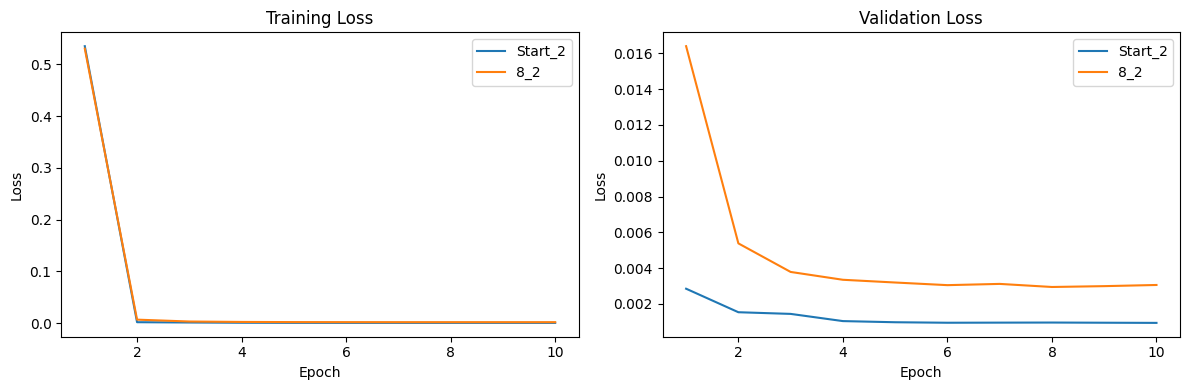

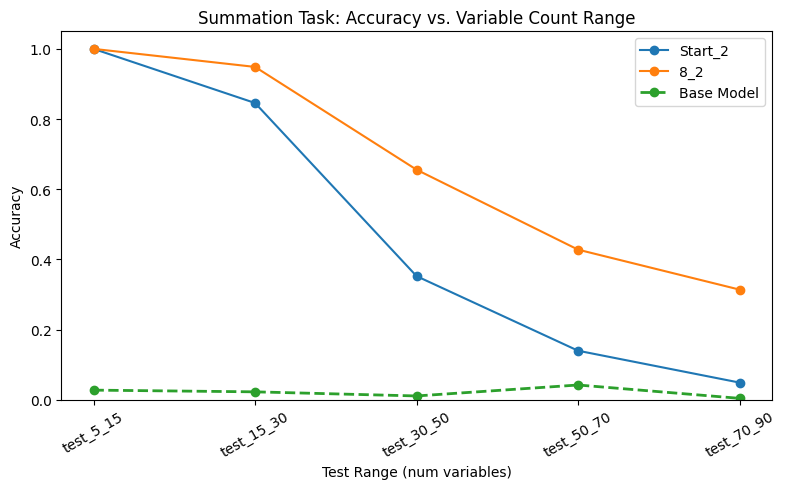

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- Loss curves (averaged over seeds) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for exp_name, res in all_results.items():
    mean_train = np.mean(res["train_losses"], axis=0)
    mean_val   = np.mean(res["val_losses"], axis=0)
    epochs_x = np.arange(1, EPOCHS + 1)

    axes[0].plot(epochs_x, mean_train, label=exp_name)
    axes[1].plot(epochs_x, mean_val,   label=exp_name)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Accuracy vs. number of variables (like paper Figure 6) ---
test_names = ["test_5_15", "test_15_30", "test_30_50", "test_50_70", "test_70_90"]#sorted(test_data.keys())

fig, ax = plt.subplots(figsize=(8, 5))

for exp_name, res in all_results.items():
    # Average accuracy across seeds for each test range.
    mean_accs = []
    for tn in test_names:
        accs = [seed_acc[tn] for seed_acc in res["accuracies"]]
        mean_accs.append(np.mean(accs))

    ax.plot(test_names, mean_accs, marker="o", label=exp_name)
ax.plot(
    test_names,
    baseline_mean_accs,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Base Model",
)
ax.set_title("Summation Task: Accuracy vs. Variable Count Range")
ax.set_xlabel("Test Range (num variables)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [28]:
logger.close() #(Only run this if you needed to terminate a run early from before, and the logger was not closed)

epoch,▁▂▃▃▄▅▆▆▇█
train/loss,█▁▁▁▁▁▁▁▁▁
train/lr,██▇▆▅▄▂▂▁▁
val/loss,█▃▂▁▁▁▁▁▁▁
epoch,10
train/loss,0.00104
train/lr,5e-05
val/loss,0.00122


In [10]:
#confirmation tests for hypothesis 1 (Generation task) that llama 3.2 tokenizer tokenizes commas separately
tests = [",", "65,", "61,78", "87@78=61,", "<BOS> 87@78=61,78@61=47,", "<BOS> Var0=15, Var1=12, Var2=24, Var3=27, Var4=21, Var5=16, Var6=25, Var7=20, Var3+Var5=", "<BOS> Var0=15, Var1=12, Var2=24, Var3=27, Var4=21, Var5=16, Var6=25, Var7=20, Var3+Var5=27+16=43<EOS>"]

for text in tests:
    ids = tokenizer.encode(text, add_special_tokens=False)
    toks = tokenizer.convert_ids_to_tokens(ids)
    print("TEXT:", repr(text))
    print("IDS: ", ids)
    print("TOKS:", toks)
    print()

TEXT: ','
IDS:  [11]
TOKS: [',']

TEXT: '65,'
IDS:  [2397, 11]
TOKS: ['65', ',']

TEXT: '61,78'
IDS:  [5547, 11, 2495]
TOKS: ['61', ',', '78']

TEXT: '87@78=61,'
IDS:  [4044, 31, 2495, 28, 5547, 11]
TOKS: ['87', '@', '78', '=', '61', ',']

TEXT: '<BOS> 87@78=61,78@61=47,'
IDS:  [33619, 3204, 29, 220, 4044, 31, 2495, 28, 5547, 11, 2495, 31, 5547, 28, 2618, 11]
TOKS: ['<B', 'OS', '>', 'Ġ', '87', '@', '78', '=', '61', ',', '78', '@', '61', '=', '47', ',']

TEXT: '<BOS> Var0=15, Var1=12, Var2=24, Var3=27, Var4=21, Var5=16, Var6=25, Var7=20, Var3+Var5='
IDS:  [33619, 3204, 29, 8909, 15, 28, 868, 11, 8909, 16, 28, 717, 11, 8909, 17, 28, 1187, 11, 8909, 18, 28, 1544, 11, 8909, 19, 28, 1691, 11, 8909, 20, 28, 845, 11, 8909, 21, 28, 914, 11, 8909, 22, 28, 508, 11, 8909, 18, 10, 4050, 20, 28]
TOKS: ['<B', 'OS', '>', 'ĠVar', '0', '=', '15', ',', 'ĠVar', '1', '=', '12', ',', 'ĠVar', '2', '=', '24', ',', 'ĠVar', '3', '=', '27', ',', 'ĠVar', '4', '=', '21', ',', 'ĠVar', '5', '=', '16', ',', 'ĠVar', 

# Generation Task Experiment (Hypothesis 1)
Reimplementation of the self-prompting for long and consistent generation task (Section 4.1) from the Latent Tokens paper.
Insertion strategies: Start_2 and Comma_2.

In [17]:
#load synthetic data

GEN_DATA_DIR = Path(PROJECT_ROOT) / "data" / "generation"

gen_train_data = load_jsonl(GEN_DATA_DIR / "train.jsonl")
gen_val_data   = load_jsonl(GEN_DATA_DIR / "val.jsonl")

gen_test_files = sorted(GEN_DATA_DIR.glob("test_*.jsonl"))
gen_test_data  = {f.stem: load_jsonl(f) for f in gen_test_files}

print(f"Gen Train samples: {len(gen_train_data)}")
print(f"Gen Val samples:   {len(gen_val_data)}")
for name, samples in gen_test_data.items():
    print(f"  {name}: {len(samples)} samples  (response_eqs={samples[0]['response_equations']}, max_new_tokens={samples[0]['max_new_tokens']})")

Gen Train samples: 4096
Gen Val samples:   1024
  test_10_60: 1024 samples  (response_eqs=10, max_new_tokens=60)
  test_30_180: 1024 samples  (response_eqs=30, max_new_tokens=180)
  test_50_300: 1024 samples  (response_eqs=50, max_new_tokens=300)
  test_60_360: 1024 samples  (response_eqs=60, max_new_tokens=360)


In [18]:
# get comma token id:
COMMA_TOKEN_ID = tokenizer.encode(",", add_special_tokens=False)[0]
print(f"Comma token id: {COMMA_TOKEN_ID}")

Comma token id: 11


In [19]:
#tokenize generation data
gen_train_tok = [tokenize_sample(s, tokenizer, append_eos=False) for s in gen_train_data]
gen_val_tok   = [tokenize_sample(s, tokenizer, append_eos=False) for s in gen_val_data]
gen_test_tok  = {name: [tokenize_sample(s, tokenizer, append_eos=False) for s in samples]
                 for name, samples in gen_test_data.items()}

print(f"Gen Train token lengths: min={min(len(s['input_ids']) for s in gen_train_tok)}, "
      f"max={max(len(s['input_ids']) for s in gen_train_tok)}")
print(f"Gen Val token lengths:   min={min(len(s['input_ids']) for s in gen_val_tok)}, "
      f"max={max(len(s['input_ids']) for s in gen_val_tok)}")
for name, samples in gen_test_tok.items():
    print(f"  {name} token lengths: min={min(len(s['input_ids']) for s in samples)}, "
          f"max={max(len(s['input_ids']) for s in samples)}")

Gen Train token lengths: min=36, max=90
Gen Val token lengths:   min=36, max=90
  test_10_60 token lengths: min=90, max=90
  test_30_180 token lengths: min=210, max=210
  test_50_300 token lengths: min=330, max=330
  test_60_360 token lengths: min=390, max=390


In [23]:
#Hyperparams + logging config for generation task
GEN_MAX_NEW_TOKENS_DEFAULT = 360
SEEDS = [1, 2, 3]     #(paper averages over 3 seeds)
GEN_LOG_CFG = LoggingConfig(
    output_root="/content/drive/MyDrive/LatentTokensReimplementation/outputs/generation_experiment",
    use_wandb=True,
    wandb_project="latent_tokens_generation_hyp1",
    wandb_entity="bostrower3-georgia-institute-of-technology",
    checkpoint_every=1,
    save_best=True,
    save_last=True,
)

In [24]:
def parse_equations(text):
    """Split a comma-delimited equation string into individual equations."""
    return [eq.strip() for eq in text.split(",") if eq.strip()]


@torch.no_grad()
def evaluate_equation_accuracy(model, raw_samples, tokenizer, comma_token_id=None):
    """
    Generate continuations for each sample and measure equation-level accuracy.
    Returns: fraction of correct equations across all samples
             (total_correct / total_expected).
    """
    model.eval()
    dev = model.latent_embeddings.weight.device
    total_correct = 0
    total_expected = 0

    for sample in raw_samples:
        query = sample["query"].replace("<BOS>", "").strip()
        query_ids = tokenizer.encode(query, add_special_tokens=False)
        input_ids = torch.tensor([query_ids], dtype=torch.long, device=dev)

        max_new_tokens = sample["max_new_tokens"]
        expected_equations = sample["response_equations"]

        output_ids = model.generate(
            input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            comma_token_id=comma_token_id,
            eos_token_id=None,
        )

        new_ids = output_ids[0, len(query_ids):].tolist()
        generated = tokenizer.decode(new_ids, skip_special_tokens=True)

        gen_eqs = parse_equations(generated)
        gt_eqs  = parse_equations(sample["response"])

        correct = sum(
            1 for g, t in zip(gen_eqs, gt_eqs) if g == t
        )
        total_correct += correct
        total_expected += expected_equations

    return total_correct / total_expected if total_expected > 0 else 0.0

In [25]:
#run generation task experiments
gen_experiments = {
    "Gen_Start_2": {"strategy": "start", "period": None, "num_latent": 2, "comma_id": None},
    "Gen_Comma_2": {"strategy": "comma", "period": None, "num_latent": 2, "comma_id": COMMA_TOKEN_ID},
}

gen_all_results = {}

for exp_name, exp_cfg in gen_experiments.items():
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"{'='*60}")

    seed_train_losses = []
    seed_val_losses = []
    seed_accuracies = []
    cid = exp_cfg["comma_id"]

    for seed in SEEDS:
        print(f"\n--- Seed {seed} ---")
        model, optimizer, scheduler = setup_experiment(
            strategy=exp_cfg["strategy"],
            period=exp_cfg["period"],
            num_latent=exp_cfg["num_latent"],
            seed=seed,
            train_size=len(gen_train_tok),
        )
        logger = ExperimentLogger(
            cfg=GEN_LOG_CFG,
            exp_name=exp_name,
            seed=seed,
            model_config=model.config,
            train_hparams={
                "lr": LR,
                "min_lr": MIN_LR,
                "epochs": EPOCHS,
                "batch_size": BATCH_SIZE,
                "warmup_ratio": WARMUP_RATIO,
                "weight_decay": WEIGHT_DECAY,
            },
        )
        train_losses = []
        val_losses = []
        for epoch in range(EPOCHS):
            t_loss = train_one_epoch(model, optimizer, scheduler,
                                     epoch_seed=seed * 100 + epoch,
                                     dataset=gen_train_tok,
                                     comma_token_id=cid)
            v_loss = eval_loss(model, gen_val_tok, comma_token_id=cid)
            train_losses.append(t_loss)
            val_losses.append(v_loss)

            current_lr = optimizer.param_groups[0]["lr"]
            logger.log_epoch(
                epoch=epoch + 1,
                train_loss=t_loss,
                val_loss=v_loss,
                lr=current_lr,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
            )

            print(f"  Epoch {epoch+1}/{EPOCHS}  train_loss={t_loss:.4f}  val_loss={v_loss:.4f}")

        seed_train_losses.append(train_losses)
        seed_val_losses.append(val_losses)

        accs = {}
        for test_name, raw_samples in gen_test_data.items():
            acc = evaluate_equation_accuracy(model, raw_samples, tokenizer,
                                             comma_token_id=cid)
            accs[test_name] = acc
            print(f"  {test_name} equation accuracy: {acc:.4f}")

        seed_accuracies.append(accs)

        logger.log_test_metrics(accs)
        logger.save_final(model=model, optimizer=optimizer, scheduler=scheduler, final_epoch=EPOCHS)
        logger.close()

        del model, optimizer, scheduler
        torch.cuda.empty_cache()

    gen_all_results[exp_name] = {
        "train_losses": seed_train_losses,
        "val_losses": seed_val_losses,
        "accuracies": seed_accuracies,
    }


Experiment: Gen_Start_2

--- Seed 1 ---


NameError: name 'MAX_NEW_TOKENS' is not defined